# Assignment 1: Wrangling and EDA
### Foundations of Machine Learning

In [ ]:
import urllib.request
import os
import zipfile
import os

def download_data(force=False):
    """Download and extract course data from Zenodo."""

    zip_path = 'data.zip'
    data_dir = './data'

    if not os.path.exists(zip_path) or force:
        print("Downloading course data...")
        urllib.request.urlretrieve(
            'https://zenodo.org/records/18235955/files/data.zip?download=1',
            zip_path
        )
        print("Download complete")

    if not os.path.exists(data_dir) or force:
        print("Extracting data files...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(data_dir)
        print("Data extracted")

    return data_dir


if __name__ == "__main__":
    download_data()


Download complete
Extracting data files...
Data extracted


**Q1.** This question provides some practice cleaning variables which have common problems.
1. Numeric variable: For `airbnb_NYC.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)

I did three things to the Price variable to clean it. First, I wrote code to drop any possible "$" and "," characters inside any of the values. This would convert these numbers into a more compatible format when I convert them into a numeric form of data. Doing this results in no missing values at least to .isna as a result of 0 is achieved.

2. Categorical variable: For the Minnesota police use of for data, `mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing? For the remaining missing values, replace the `np.nan/None` values with the label `Missing`.

The number of missing values seems to be 9848 out of seemingly a length of 12925. After cross-tabulation, there seems to be a pretty vague pattern of less intense force_type gaining a higher proportion of non-missing values. Some of the more, say aggressive force_types tend to have massive amounts of missing values. This perhaps make sense in the context of police work since given the benefit of the doubt, taking data of a subject_injury may have been overlooked with a more intense type of interaction.

3. Dummy variable: For `metabric.csv`, convert the `Overall Survival Status` variable into a dummy/binary variable, taking the value 0 if the patient is deceased and 1 if they are living.

Done.

4. Missing values: For `airbnb_NYC.csv`, determine how many missing values of `Review Scores Rating` there are. Create a new variable, in which you impute the median score for non-missing observations to the missing ones. Why might this bias or otherwise negatively impact your results?

There are 8323 missing values according to the code below. The fundamental issue with simply replacing missing values with medians is that the concept that a review is missing alone is information. We are inherently assuming here that every missing review is simply just "average" that is taken across every experience given, which is likely not the case. Also, it seems like we are taking the median using data from multiple different experiences and even locations, which would be a faulty use of information since we are giving a specific location a median computed with data not from that specific location. This could artificially bias or cover up or even reduce the true rating of a airbnb. The assumption that a missing review automatically equates to a median of multiple different locations that is not even from it can not be true in most cases. We can not assume what a "missing" score would be.


In [ ]:
#needed
import pandas as pd
import os

from google.colab import files
uploaded = files.upload()

Saving GSAF5.xls to GSAF5.xls


In [ ]:
#1
df = pd.read_csv("airbnb_hw.csv")
print(df["Price"])
df["cleaned"] = df["Price"].str.replace("$","")
df["cleaned"] = df["cleaned"].str.replace(",","")
df["cleaned"] = pd.to_numeric(df["cleaned"],errors="coerce")
print(df["cleaned"])
print(df["cleaned"].isna().sum())

In [ ]:
#2
df = pd.read_csv("mn_police_use_of_force.csv")
print(df["subject_injury"])
print(df["subject_injury"].isna().sum())
df["subject_injury"] = df["subject_injury"].fillna("Missing")
print(df["subject_injury"])
pd.crosstab(df["subject_injury"], df["force_type"])

0        NaN
1        NaN
2        NaN
3        NaN
4        NaN
        ... 
12920    NaN
12921    NaN
12922    NaN
12923    NaN
12924    NaN
Name: subject_injury, Length: 12925, dtype: object
9848
0        Missing
1        Missing
2        Missing
3        Missing
4        Missing
          ...   
12920    Missing
12921    Missing
12922    Missing
12923    Missing
12924    Missing
Name: subject_injury, Length: 12925, dtype: object


force_type,Baton,Bodily Force,Chemical Irritant,Firearm,Gun Point Display,Improvised Weapon,Less Lethal,Less Lethal Projectile,Maximal Restraint Technique,Police K9 Bite,Taser
subject_injury,,,,,,,,,,,
Missing,2,7051,1421,0,27,74,87,0,170,31,985
No,0,1093,131,2,33,34,0,1,0,2,150
Yes,2,1286,41,0,44,40,0,2,0,44,172


In [ ]:
#3
import pandas as pd
import os
df = pd.read_csv("/content/data/metabric.csv")
print(df["Overall Survival Status"])
dict = {"0:LIVING":1, "1:DECEASED":0}
df["Overall Survival Status Binary"] = df["Overall Survival Status"].map(dict)
print(df["Overall Survival Status Binary"])

0         0:LIVING
1       1:DECEASED
2         0:LIVING
3       1:DECEASED
4       1:DECEASED
           ...    
1338      0:LIVING
1339    1:DECEASED
1340      0:LIVING
1341    1:DECEASED
1342      0:LIVING
Name: Overall Survival Status, Length: 1343, dtype: object
0       1
1       0
2       1
3       0
4       0
       ..
1338    1
1339    0
1340    1
1341    0
1342    1
Name: Overall Survival Status Binary, Length: 1343, dtype: int64


In [ ]:
import pandas as pd
import os
df = pd.read_csv("/content/data/airbnb_NYC.csv", encoding="latin1")
print(df["Review Scores Rating"])
print(df["Review Scores Rating"].isna().sum())
median = df["Review Scores Rating"].median()
df["Review Scores Rating new"] = df["Review Scores Rating"]
df["Review Scores Rating new"] = df["Review Scores Rating new"].fillna(median)
print(df["Review Scores Rating new"])

0         NaN
1         NaN
2         NaN
3         NaN
4        96.0
         ... 
30473     NaN
30474     NaN
30475     NaN
30476     NaN
30477     NaN
Name: Review Scores Rating, Length: 30478, dtype: float64
8323
0        94.0
1        94.0
2        94.0
3        94.0
4        96.0
         ... 
30473    94.0
30474    94.0
30475    94.0
30476    94.0
30477    94.0
Name: Review Scores Rating new, Length: 30478, dtype: float64


**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks.

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work. What does work?

You need to use a specialized read for excel.

2. Drop any columns that do not contain data.
3. What is an observation? Carefully justify your answer, and explain how it affects your choices in cleaning and analyzing the data.

An observation is ultimately a single data point or in this case, a row that has values from columns that describes one instnace. This affects my choices in cleaning and analyzing the data due to the factors of data purity and data consistency. For example, if an observation has missing data in many columns, the question becomes how to meaningfully include the row in calculations and so forth. Do I remove a column that is filled in for some observations but is not filled in for others? Is the loss of a dimension/column worth the trade-off in the loss of an "observation?" Ultimately, knowing that each row in most cases represents a single instance, or an "observation", tells me what I need to be looking at in terms of data analysis, as those are my individual data points.

4. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?

After cleaning the year variable, the range of values is interesting. The max is 2026 which is normal. However, the minimum ends up being "0" and even when I try to exclude rows with "0", there is a value like "5.0" and this is consistent when I read the data myself. Based on the data that has values from the literal B.C. era, these 0 numbers are actually intentional to signify it is before A.D. Attacks are technically increasing since about 1970, but there appears to be a huge peak at around 1960. Shark attacks were increasing from 1940 to 1960, and then there was a huge drop in shark attacks around 1970, and the rate is slowly increasing once again.

5. Clean the Age variable and make a histogram of the ages of the victims.

Done. Victims seem to be predominantly around 20.

6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

About 83% or so.

7. Clean the `Fatal Y/N` variable so it only takes three values: Y, N, and Unknown.

Done.

8. Is the attack more or less likely to be fatal when the attack is provoked or unprovoked? Thoughts?

The attack is more likely to be fatal when the attack is unprovoked. This is actaully weird to me as you would imagine that a shark would more violently attack and me less willing to let go if a human goes out of their way to "threaten" them in a way that is credible. If a human is attacked unprovoked, you would imagine a shark that does not normally feed on humans to let go once it discovers it is not the usual target it thinks it is. Therefore, at first glance this result is surprising to me. However, it is very possible that in a provoked encounter, the human determines the circumstance of "engagement" so the shark's ability to do damage is mitigated, while in an unprovoked situation, the human is caught in a vulnerable state.

0       2026.0
1       2026.0
2       2026.0
3       2026.0
4       2026.0
         ...  
7069       0.0
7070       0.0
7071       0.0
7072       0.0
7073       0.0
Name: Year, Length: 7074, dtype: float64
2026.0
0.0
0       2026.0
1       2026.0
2       2026.0
3       2026.0
4       2026.0
         ...  
5535    1940.0
5536    1940.0
5537    1940.0
5538    1940.0
5539    1940.0
Name: Year, Length: 5538, dtype: float64


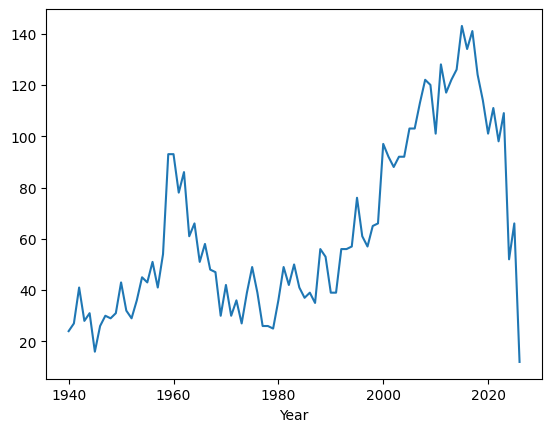

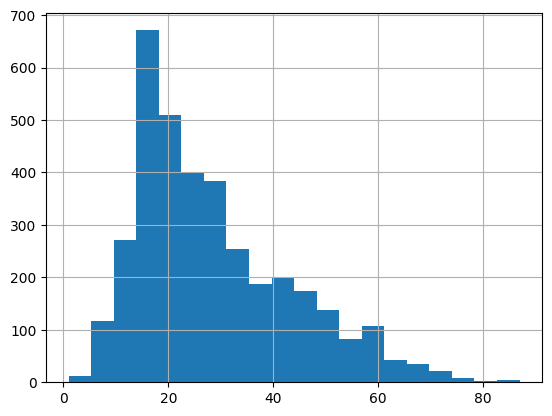

0       Unprovoked
3       Unprovoked
4       Unprovoked
5       Unprovoked
6       Unprovoked
           ...    
5528    Unprovoked
5529    Unprovoked
5530    Unprovoked
5531    Unprovoked
5532    Unprovoked
Name: Type, Length: 3622, dtype: object
3014


Type,Provoked,Unknown,Unprovoked
Fatal Y/N,,,
N,283,87,2501
Unknown,3,195,18
Y,8,32,495


In [44]:
import pandas as pd
import os
df = pd.read_excel("GSAF5.xls")
df = df.dropna(axis=1, how="all")
print(df["Year"])
df["Year"] = pd.to_numeric(df["Year"],errors="coerce")
df = df[df["Year"].notna()]
print(df["Year"].max())
print(df["Year"].min())
df = df[df["Year"] >= 1940]
print(df["Year"])

import matplotlib.pyplot as plt

df.groupby("Year").size().plot(kind="line")
plt.show()

df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
df = df[df["Age"].notna()]
df["Age"].hist(bins=20)
plt.show()

df["Type"] = df["Type"].str.strip().str.capitalize()
df["Type"] = df["Type"].fillna("Unknown")
for entry in df["Type"].index:
    if df.at[entry, "Type"] != "Unprovoked" and df.at[entry, "Type"] != "Provoked":
      df.at[entry, "Type"] = "Unknown"
print(df["Type"])
print((df["Type"] == "Unprovoked").sum())

df["Fatal Y/N"] = df["Fatal Y/N"].str.strip().str.capitalize()
for entry in df["Fatal Y/N"].index:
    if df.at[entry, "Fatal Y/N"] != "Y" and df.at[entry, "Fatal Y/N"] != "N":
      df.at[entry, "Fatal Y/N"] = "Unknown"

pd.crosstab(df["Fatal Y/N"], df["Type"])




**Q3.** Open the "tidy_data.pdf" document available in `https://github.com/ds4e/wrangling`, which is a paper called *Tidy Data* by Hadley Wickham.

  1. Read the abstract. What is this paper about?

  The paper explores a claimed underrated aspect of data cleaning: data tidying. It appears the paper is proposing a specific framework to make data tidying as easy as possible with each column as a variable, each row as an observation, and each table as a set of observations. The paper seems to advocate for data tidying to be used more widespread due to easy of use, efficiency, and the creation of a more standardized form of data.

  2. Read the introduction. What is the "tidy data standard" intended to accomplish?

  The tidy data standard aims to make data cleaning more efficient so the user does not have to "reinvent the wheel" tackling each new data set. Having a level of standardization and organization among data sets allows users to be able to use premade tidy tools that translate well across many types of data. Although certain fields have made advancements in efficient data structure, this tidy data standard is going to be an easily accessible language more accessible to statisticians.

  3. Read the intro to section 2. What does this sentence mean: "Like families, tidy datasets are all alike but every messy dataset is messy in its own way." What does this sentence mean: "For a given dataset, it’s usually easy to figure out what are observations and what are variables, but it is surprisingly difficult to precisely define variables and observations in general."

  The first quote quite literally indicates that though all tidy data sets will be alike in structure, nodding to the generally increased efficiency and standardization that follows this model, messy data sets are going to have messy issues in their own unique way and will not be messay in a standardized fashion that will be easy to fix. There is no one-size-fits-all for messy data sets is what the author is getting at. The second quote compares the ability to just identify what are precisely "observations" and "variables" but in practicality, it is very difficult to define these in a context that is useful. Sometimes, the column labels may be straight forward but in some cases, the placement of some columns might just not make sense to the goal we are trying to do and thus requires an overhaul. Some columns may be confusing as they seem to be belonging to a common "dimension" variable rather than split in two, and it is important to further distinguish bewteen observations and variables. There is a level of vagueness in what each variable means and even if it is clear, there are variables that will cause problems in data analysis that requires editing in a data table. The author then goes into relationships to help the reader spot the difference between variable relationships and observation relationships to provide some clarity.

  4. Read Section 2.2. How does Wickham define values, variables, and observations?

  A data set is composed of values that are usually either a number or a string. Values belong to a variable and an observation. A variable contains values that all measure the same underlying attribute according to the author. An observation contains all the values measured on the same unit across all of these attributes.

  5. How is "Tidy Data" defined in section 2.3?

  The three principles in "Tidy Data" are: each variable is a column, each observation forms a row, and each type of observational unit forms a table.

  6. Read the intro to Section 3 and Section 3.1. What are the 5 most common problems with messy datasets? Why are the data in Table 4 messy? What is "melting" a dataset?

  The 5 most common problems with messy datasets are: column headers being values and not names, multiple variables stored in one column, variables stored in both rows and columns, multiple types of observational units being stored in the same table, and a single observational unit being stored in many tables. Table 4 is messy because the rows, columns, and column headers are values rather than variable names. Melting a data set refers to turning columns into rows or being paramatized by colvars and then creating two new columns: column that contains repeated column headings and value that contains concatenated data from those separated columns.

  7. Why, specifically, is table 11 messy but table 12 tidy and "molten"?

  Table 11 specifically has variables stored in both columns and rows. Table 12 instead melts it with colvars id, year, month, and the column that contains variable names like element. To fix the rows, a cast or unstack operation was done to establish each column as one variable and each row as one day of observation.

**Q4.** This question looks at financial transfers from international actors to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going?

For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.

Due to the presence of extremely high amount outliers, the histogram structure looks less than ideal. There are a couple high value outliers that are ultimately skewing the distribution to make the histogram less readable, despite the vast majority of cases being close to smaller amounts. In terms of the variable description, it is frankly pretty hard to find trends because the mean is unreliable due to extremely high outliers in the data. However, it appears that the 50th percentile around 9.5 * 10^4 seems to be somewhat representative and more reasonable than the massive 10^8 at the edge of the x axis. It might appear that most data points fall in a range of say in the thousands to the hundred thousands and that this data set has extreme high outliers.

3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?

Monetary Gift: 0.388
Contracts: 0.612
Real Estate: 0.0004

4. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?

Number of Gifts:
ENGLAND,
CHINA,
CANADA,
JAPAN,
SWITZERLAND,
SAUDI ARABIA,
FRANCE,
GERMANY,
HONG KONG,
SOUTH KOREA,
QATAR,
THE NETHERLANDS,
KOREA,
INDIA,
TAIWAN

Amount Given:
QATAR,
ENGLAND,
CHINA,
SAUDI ARABIA,
BERMUDA,
CANADA,
HONG KONG,
JAPAN,
SWITZERLAND,
INDIA,
GERMANY,
UNITED ARAB EMIRATES,
FRANCE,
SINGAPORE,
AUSTRALIA

5. What are the top 15 institutions in terms of the total amount of money they receive? Make a histogram of the total amount received by all institutions.

Carnegie Mellon University,
Cornell University,
Harvard University,
Massachusetts Institute of Technology,
Yale University,
Texas A&M University,
Johns Hopkins University,
Northwestern University,
Georgetown University,
University of Chicago (The),
University of Colorado Boulder,
Duke University,
Brigham Young University,
Stanford University,
University of Texas MD Anderson Cancer Center

6. Which giftors provide the most money, in total?
Qatar Foundation,
Qatar Foundation/Qatar National Res,
Qatar Foundation for Education,
Anonymous,
Saudi Arabian Cultural Mission,
HCL,
Church of Jesus Christ of LDS,
Emirates Institute for Advanced Sc,
QIC,
Anonymous #9,
Qatar National Research Fund,
Government of Saudi Arabia,
Contracting Party,
CMKL University,
Royal Embassy of Saudi Arabia

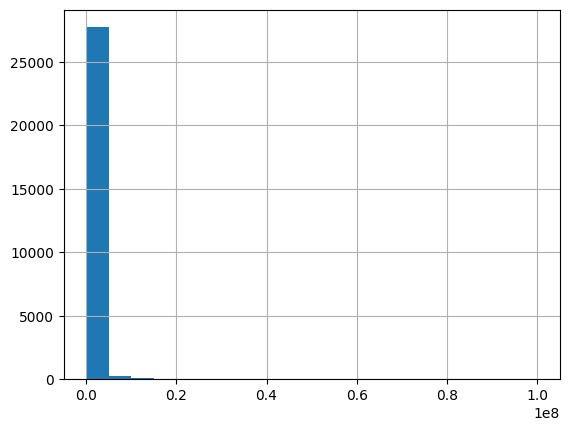

count    2.819700e+04
mean     5.887770e+05
std      3.223327e+06
min      1.000000e+00
25%      5.793000e+03
50%      9.509100e+04
75%      3.767520e+05
max      1.000000e+08
Name: Foreign Gift Amount, dtype: float64
0         250000
1         463657
2        3649107
3           1000
4          49476
          ...   
28216     381717
28217     444938
28218    1064580
28219     737375
28220    1024469
Name: Foreign Gift Amount, Length: 28197, dtype: int64


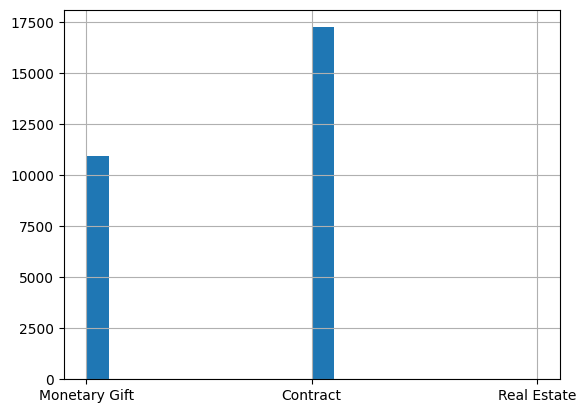

10936
17250
11
0        Monetary Gift
1             Contract
2             Contract
3             Contract
4             Contract
             ...      
28216         Contract
28217         Contract
28218         Contract
28219         Contract
28220    Monetary Gift
Name: Gift Type, Length: 28197, dtype: object
Country of Giftor
ENGLAND            3654
CHINA              2461
CANADA             2344
JAPAN              1891
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1433
GERMANY            1393
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
Name: count, dtype: int64
Country of Giftor
QATAR                   2706240869
ENGLAND                 1464933703
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN              

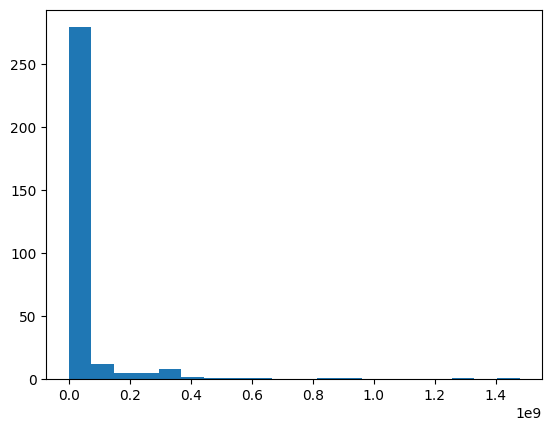

Giftor Name
Qatar Foundation                       1166503744
Qatar Foundation/Qatar National Res     796197000
Qatar Foundation for Education          373945215
Anonymous                               338793629
Saudi Arabian Cultural Mission          275221475
HCL                                     190000000
Church of Jesus Christ of LDS           185203715
Emirates Institute for Advanced Sc      170641244
QIC                                     148355497
Anonymous #9                             96334996
Qatar National Research Fund             79021705
Government of Saudi Arabia               75192434
Contracting Party                        69996984
CMKL University                          67700000
Royal Embassy of Saudi Arabia            67062486
Name: Foreign Gift Amount, dtype: int64


In [63]:
import pandas as pd
import os
df = pd.read_csv("/content/data/ForeignGifts_edu.csv")
df = df[df["Foreign Gift Amount"] >= 0]
df["Foreign Gift Amount"].hist(bins=20)
plt.show()

print(df["Foreign Gift Amount"].describe())
print(df["Foreign Gift Amount"])

df["Gift Type"].hist(bins=20)
plt.show()

print((df["Gift Type"] == "Monetary Gift").sum())
print((df["Gift Type"] == "Contract").sum())
print((df["Gift Type"] == "Real Estate").sum())
print(df["Gift Type"])

print(df["Country of Giftor"].value_counts().head(15))
print(df.groupby("Country of Giftor")["Foreign Gift Amount"].sum().sort_values(ascending=False).head(15))

print(df.groupby("Institution Name")["Foreign Gift Amount"].sum().sort_values(ascending=False).head(15))

college = df.groupby("Institution Name")["Foreign Gift Amount"].sum()
plt.hist(college, bins=20)
plt.show()

print(df.groupby("Giftor Name")["Foreign Gift Amount"].sum().sort_values(ascending=False).head(15))

**Q5.** This question provides some practice doing exploratory data analysis and visualization.

We'll use the `college_completion.csv` dataset from the US Department of Education. The "relevant" variables for this question are:
  - `level` - Level of institution (4-year, 2-year)
  - `aid_value` - The average amount of student aid going to undergraduate recipients
  - `control` - Public, Private not-for-profit, Private for-profit
  - `grad_100_value` - percentage of first-time, full-time, degree-seeking undergraduates who complete a degree or certificate program within 100 percent of expected time (bachelor's-seeking group at 4-year institutions)

1. Load the `college_completion.csv` data with Pandas.
2. How many observations and variables are in the data? Use `.head()` to examine the first few rows of data.

There appears to be 3798 observations and 63 variables.

3. Cross tabulate `control` and `level`. Describe the patterns you see in words.

Private for-profit institutions tend to have a roughly even split bewteen 2-year and 4-year status. Private not-for-profit institutions tend to be majority 4-year status with a large margin while public institutions tend to favor 2-year status slightly.  

4. For `grad_100_value`, create a kernel density plot and describe table. Now condition on `control`, and produce a kernel density plot and describe tables for each type of institutional control. Which type of institution appear to have the most favorable graduation rates?

Private not-for-profit appears to have the most favorable graduation rates based on the plot and the describe variables.

5. Make a scatterplot of `grad_100_value` by `aid_value`, and compute the covariance and correlation between the two variables. Describe what you see. Now make the same plot and statistics, but conditioning on `control`. Describe what you see. For which kinds of institutions does aid seem to vary positively with graduation rates?

Aid seems to vary positively with gradution rate wih every kind of institution to varying extents, but private not-for-profit institutions have the strongest positive correlation between aid and graduation rates. The link bewteen these two variables for private for-profit was the weakest.

   index  unitid                            chronname        city    state  \
0      0  100654               Alabama A&M University      Normal  Alabama   
1      1  100663  University of Alabama at Birmingham  Birmingham  Alabama   
2      2  100690                   Amridge University  Montgomery  Alabama   
3      3  100706  University of Alabama at Huntsville  Huntsville  Alabama   
4      4  100724             Alabama State University  Montgomery  Alabama   

    level                 control  \
0  4-year                  Public   
1  4-year                  Public   
2  4-year  Private not-for-profit   
3  4-year                  Public   
4  4-year                  Public   

                                               basic hbcu flagship  ...  \
0  Masters Colleges and Universities--larger prog...    X      NaN  ...   
1  Research Universities--very high research acti...  NaN      NaN  ...   
2            Baccalaureate Colleges--Arts & Sciences  NaN      NaN  ...   
3  Resea

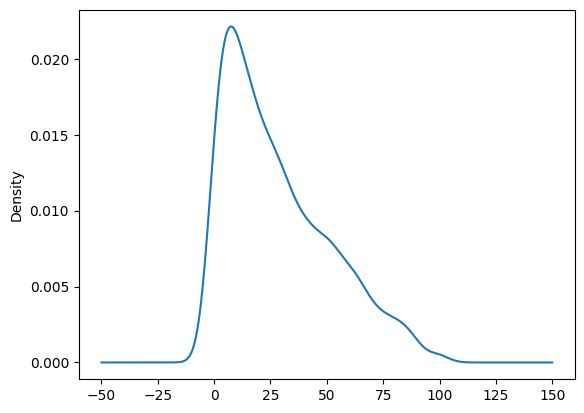

                         count       mean        std  min    25%   50%    75%  \
control                                                                         
Private for-profit       779.0  29.108858  25.601687  0.0   6.95  24.7  46.75   
Private not-for-profit  1189.0  41.660976  23.551231  0.0  25.00  41.0  58.30   
Public                  1499.0  17.430887  14.729443  0.0   6.90  13.2  23.25   

                          max  
control                        
Private for-profit      100.0  
Private not-for-profit  100.0  
Public                   97.8  


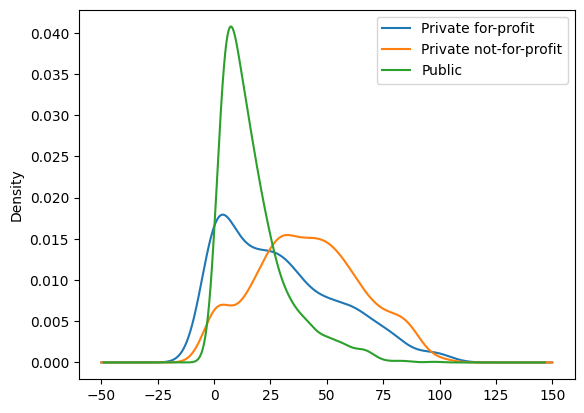

                aid_value  grad_100_value
aid_value        1.000000        0.575879
grad_100_value   0.575879        1.000000
                   aid_value  grad_100_value
aid_value       4.121201e+07    88610.483169
grad_100_value  8.861048e+04      543.483382


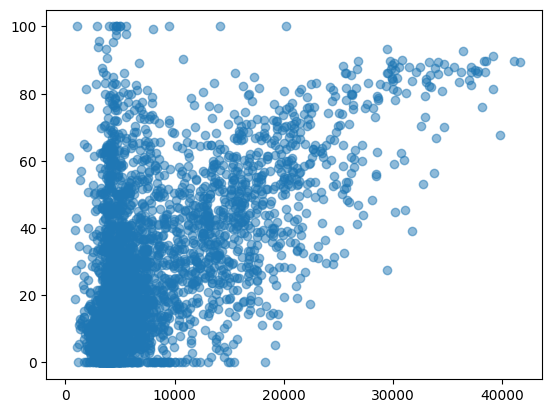

                                       aid_value  grad_100_value
control                                                         
Private for-profit     aid_value        1.000000        0.188363
                       grad_100_value   0.188363        1.000000
Private not-for-profit aid_value        1.000000        0.601591
                       grad_100_value   0.601591        1.000000
Public                 aid_value        1.000000        0.482481
                       grad_100_value   0.482481        1.000000
                                          aid_value  grad_100_value
control                                                            
Private for-profit     aid_value       1.957540e+06     6897.524957
                       grad_100_value  6.897525e+03      655.446387
Private not-for-profit aid_value       6.041488e+07   109274.123337
                       grad_100_value  1.092741e+05      554.660462
Public                 aid_value       4.564360e+06    15355.146212
    

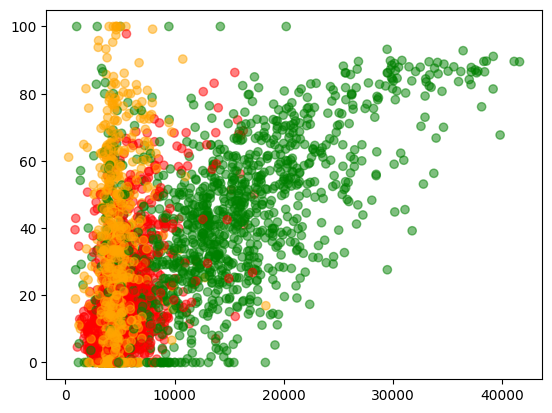

In [80]:
import pandas as pd
import os
df = pd.read_csv("/content/data/college_completion.csv")

print(df.head())

pd.crosstab(df["control"], df["level"])

print(df["grad_100_value"].describe())
df["grad_100_value"].plot(kind="kde")
plt.show()

print(df.groupby("control")["grad_100_value"].describe())
df.groupby("control")["grad_100_value"].plot(kind="kde", legend=True)
plt.show()

plt.scatter(df["aid_value"], df["grad_100_value"], alpha=0.5)
print(df[["aid_value", "grad_100_value"]].corr())
print(df[["aid_value", "grad_100_value"]].cov())
plt.show()

color = {"Public":"red", "Private for-profit":"orange", "Private not-for-profit":"green"}
plt.scatter(df["aid_value"], df["grad_100_value"], c=df["control"].map(color), alpha=0.5)
print(df.groupby("control")[["aid_value", "grad_100_value"]].corr())
print(df.groupby("control")[["aid_value", "grad_100_value"]].cov())
plt.show()

**Q6.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

We're going to look at **linear transformations** of $X$, $Y = a + bX$. So we take each value of $X$, $x_i$, and transform it as $y_i = a + b x_i$.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $ \text{cov}(X,X) = s^2$.
3. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
4. Show that $\text{cov}(a+bX,a+bY) = b^2 \text{cov}(X,Y) $. Notice, this also means that $\text{cov}(bX, bX) = b^2 s^2$.
5. Suppose $b>0$ and let the median of $X$ be $\text{med}(X)$. Is it true that the median of $a+bX$ is equal to $a + b \times \text{med}(X)$? Is the IQR of $a + bX$ equal to $a + b \times \text{IQR}(X)$?
6. Show by example that the means of $X^2$ and $\sqrt{X}$ are generally not $(m(X))^2$ and $\sqrt{m(X)}$. So, the results we derived above really depend on the linearity of the transformation $Y = a + bX$, and transformations like $Y = X^2$ or $Y = \sqrt{X}$ will not behave in a similar way.

In GitHub as a image

**Q7.** This question provides some practice doing exploratory data analysis and visualization.

We'll use the `ames_prices.csv` dataset. The "relevant" variables for this question are:
  - `price` - Sale price value of the house
  - `Bldg.Type` - Building type of the house (single family home, end-of-unit townhome, duplex, interior townhome, two-family conversion)

1. Load the `college_completion.csv` data with Pandas.
2. Make a kernel density plot of price and compute a describe table. Now, make a kernel density plot of price conditional on building type, and use `.groupby()` to make a describe type for each type of building. Which building types are the most expensive, on average? Which have the highest variance in transaction prices?

The TwnhsE buildings have the highest average and therefore are most expensive on average. The 1Fam buildings have the highest standard deviation and have the highest variance in transaction prices among these types.

3. Make an ECDF plot of price, and compute the sample minimum, .25 quantile, median, .75 quantile, and sample maximum (i.e. a 5-number summary).

Done.

4. Make a boxplot of price. Are there outliers? Make a boxplot of price conditional on building type. What patterns do you see?

Yes. There appears to be many high outliers in the data. Specifically, there appears to be many high outliers in the 1Fam category over other building categories by a significant margin. The other building categories also all have some high outliers but far less than the 1Fam category. Very few buildings have low outliers by comparison.

5. Make a dummy variable indicating that an observation is an outlier.

Done.


6. Winsorize the price variable, and compute a new kernel density plot and describe table. How do the results change?

As expected, due to the high amount of high outliers, after winsorizing the price variable, the kernel density plot shows a considerable bump at the upper bound of the winsorization. The maximum value that used to be much higher also adjusts to this new value. The lower end on the graph remains largely unchanged.

count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: price, dtype: float64


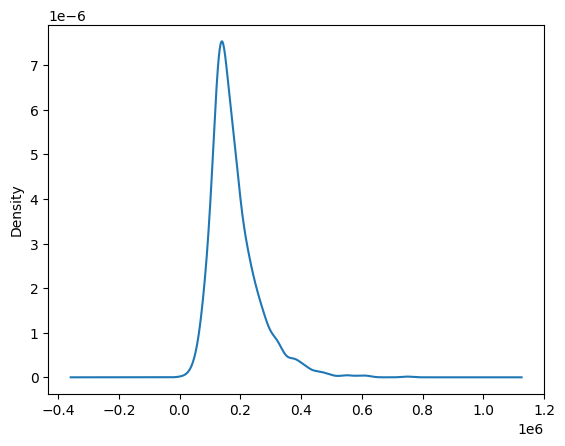

            count           mean           std      min       25%       50%  \
Bldg.Type                                                                     
1Fam       2425.0  184812.041237  82821.802329  12789.0  130000.0  165000.0   
2fmCon       62.0  125581.709677  31089.239840  55000.0  106562.5  122250.0   
Duplex      109.0  139808.935780  39498.973534  61500.0  118858.0  136905.0   
Twnhs       101.0  135934.059406  41938.931130  73000.0  100500.0  130000.0   
TwnhsE      233.0  192311.914163  66191.738021  71000.0  145000.0  180000.0   

                75%       max  
Bldg.Type                      
1Fam       220000.0  755000.0  
2fmCon     140000.0  228950.0  
Duplex     153337.0  269500.0  
Twnhs      170000.0  280750.0  
TwnhsE     222000.0  392500.0  


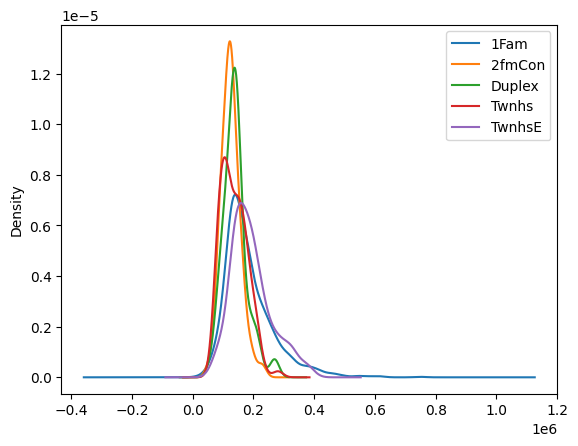

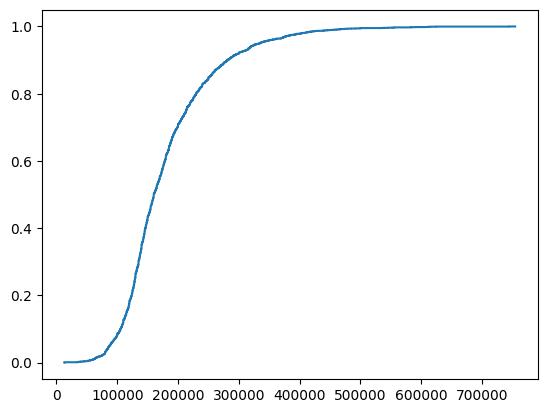

count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: price, dtype: float64


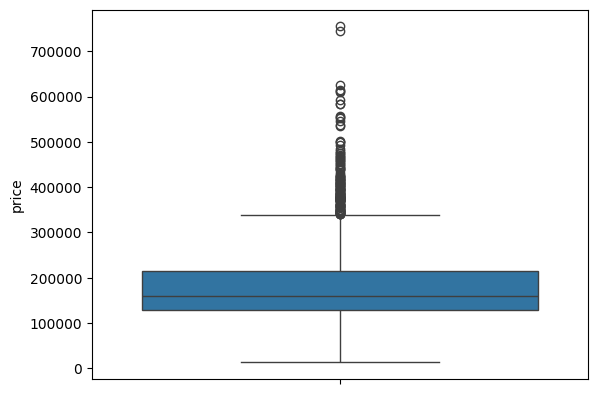

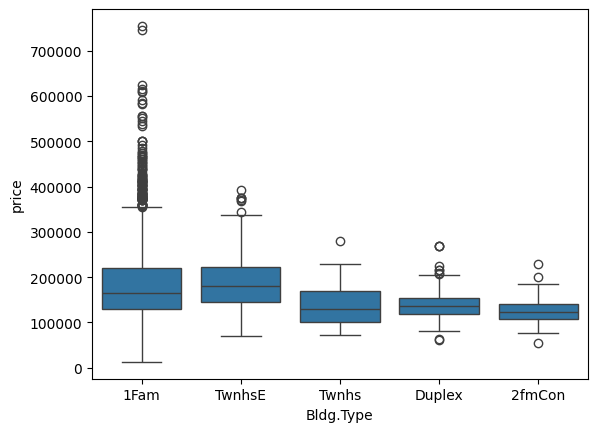

count      2930.000000
mean     177082.283959
std       67906.837135
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      339500.000000
Name: winsor, dtype: float64


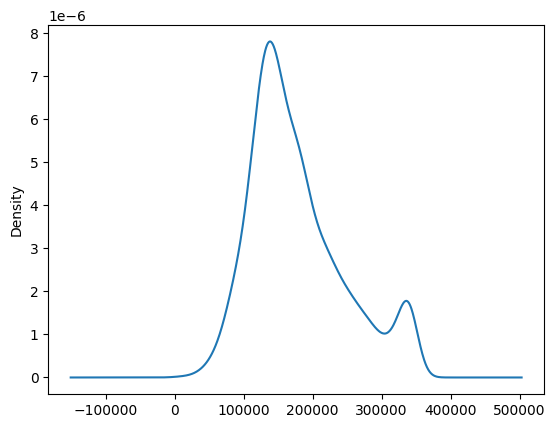

In [92]:
import pandas as pd
import os
df = pd.read_csv("/content/data/ames_prices.csv")

print(df["price"].describe())
df["price"].plot(kind="kde")
plt.show()

print(df.groupby("Bldg.Type")["price"].describe())
df.groupby("Bldg.Type")["price"].plot(kind="kde", legend=True)
plt.show()

import matplotlib.pyplot as plt
import numpy as np

x = np.sort(df["price"])
y = np.arange(1, len(x)+1) / len(x)
plt.step(x, y)
plt.show()
print(df["price"].describe())

import seaborn as sns

sns.boxplot(y=df["price"])
plt.show()
sns.boxplot(x=df["Bldg.Type"], y=df["price"])
plt.show()

Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
Inter = Q3 - Q1
min = Q1 - 1.5 * Inter
max = Q3 + 1.5 * Inter
df["outlier"] = 0
for each in df["price"].index:
  if df.loc[each, "price"] < min or df.loc[each, "price"] > max:
    df.loc[each, "outlier"] = 1

df["winsor"] = df["price"]
df["winsor"] = np.where(df["winsor"] < min, min, df["winsor"])
df["winsor"] = np.where(df["winsor"] > max, max, df["winsor"])
print(df["winsor"].describe())
df["winsor"].plot(kind="kde")
plt.show()
